In [4]:
# Step 1: Import pandas library
import pandas as pd

# Step 2: Create the dataset (30 countries example)
data = [
    ["USA", 2023, 20, 35, 30, 15, 4000],
    ["China", 2023, 55, 20, 15, 10, 7000],
    ["India", 2023, 60, 25, 10, 5, 2500],
    ["Germany", 2023, 25, 30, 25, 20, 1500],
    ["UK", 2023, 5, 35, 40, 20, 1200],
    ["France", 2023, 4, 30, 35, 31, 1100],
    ["Japan", 2023, 30, 40, 20, 10, 1600],
    ["Canada", 2023, 10, 30, 40, 20, 900],
    ["Brazil", 2023, 5, 35, 25, 35, 1000],
    ["Australia", 2023, 15, 35, 25, 25, 850],
    ["Russia", 2023, 20, 25, 50, 5, 3000],
    ["Italy", 2023, 10, 35, 30, 25, 1100],
    ["Spain", 2023, 8, 40, 25, 27, 900],
    ["South Korea", 2023, 40, 25, 20, 15, 1800],
    ["Mexico", 2023, 10, 45, 35, 10, 1200],
    ["Indonesia", 2023, 50, 30, 15, 5, 1400],
    ["Saudi Arabia", 2023, 5, 50, 40, 5, 1300],
    ["Turkey", 2023, 30, 35, 25, 10, 1000],
    ["South Africa", 2023, 70, 20, 5, 5, 800],
    ["Argentina", 2023, 2, 40, 20, 38, 700],
    ["Pakistan", 2023, 35, 30, 20, 15, 600],
    ["Nigeria", 2023, 75, 20, 3, 2, 500],
    ["Egypt", 2023, 20, 40, 25, 15, 650],
    ["Vietnam", 2023, 45, 25, 20, 10, 900],
    ["Thailand", 2023, 35, 30, 25, 10, 850],
    ["Malaysia", 2023, 40, 35, 30, 15, 750],
    ["Philippines", 2023, 30, 40, 20, 10, 700],
    ["Netherlands", 2023, 10, 35, 40, 15, 800],
    ["Sweden", 2023, 5, 30, 20, 45, 600],
    ["Norway", 2023, 2, 25, 30, 43, 550]
]

# Step 3: Define column names
columns = ["Country", "Year", "Coal (%)", "Oil (%)", "Gas (%)", "Renewables (%)", "Total Energy Consumption (TWh)"]

# Step 4: Convert data into a DataFrame
df = pd.DataFrame(data, columns=columns)

# Step 5: Display the first 5 rows of the dataset
print(df.head())

# Step 6: Save the dataset to Excel
df.to_excel("Global_Energy_Consumption.xlsx", index=False)

print("✅ Excel file created successfully!")

   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  
✅ Excel file created successfully!


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
df = pd.read_excel("Global_Energy_Consumption.xlsx")
print(df.head())

   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  


C:\Users\PTCL\AppData\Local\Temp\ipykernel_12704\3165411157.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Total Energy Consumption (TWh)", data=df, palette="viridis")


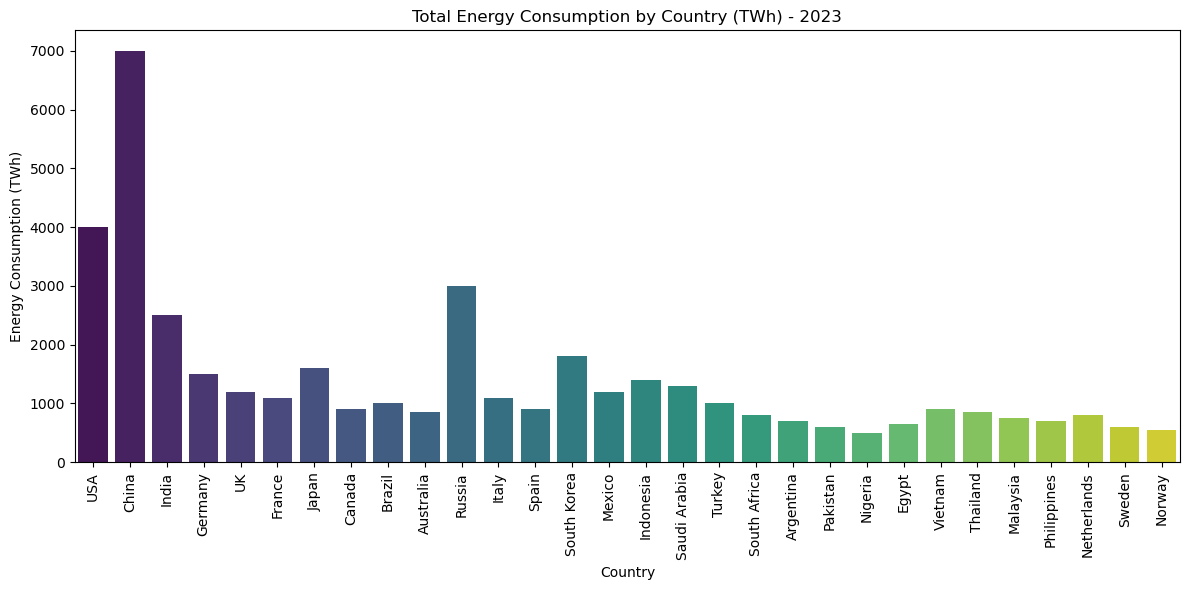

In [7]:
plt.figure(figsize=(12,6))
sns.barplot(x="Country", y="Total Energy Consumption (TWh)", data=df, palette="viridis")
plt.xticks(rotation=90)
plt.title("Total Energy Consumption by Country (TWh) - 2023")
plt.ylabel("Energy Consumption (TWh)")
plt.xlabel("Country")
plt.tight_layout()
plt.show()

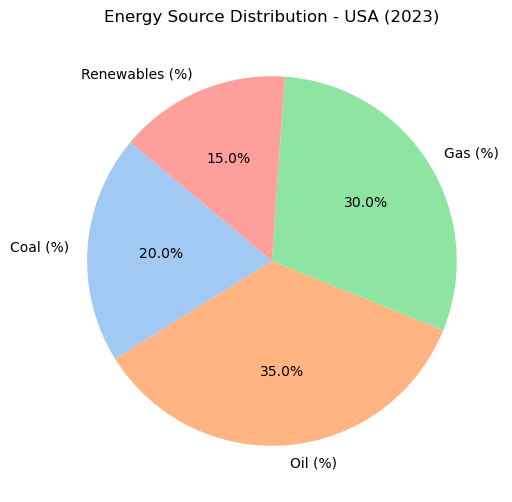

In [8]:
usa = df[df["Country"]=="USA"]
labels = ["Coal (%)", "Oil (%)", "Gas (%)", "Renewables (%)"]
sizes = usa[labels].values[0]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Energy Source Distribution - USA (2023)")
plt.show()

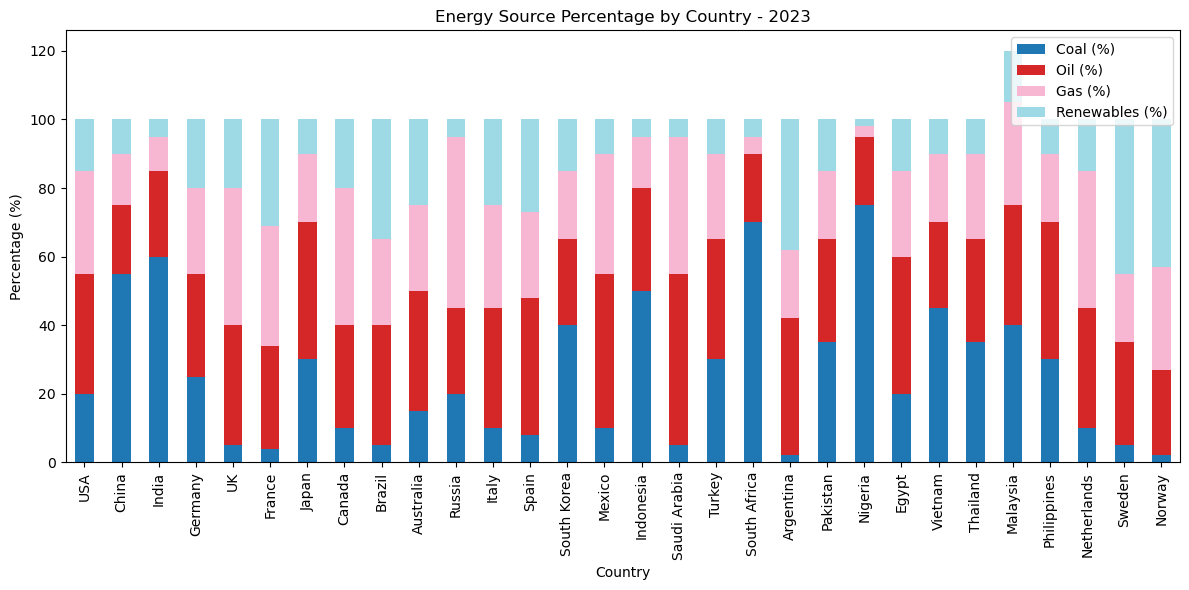

In [9]:
df_plot = df.set_index("Country")[["Coal (%)","Oil (%)","Gas (%)","Renewables (%)"]]

df_plot.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.ylabel("Percentage (%)")
plt.title("Energy Source Percentage by Country - 2023")
plt.xticks(rotation=90)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

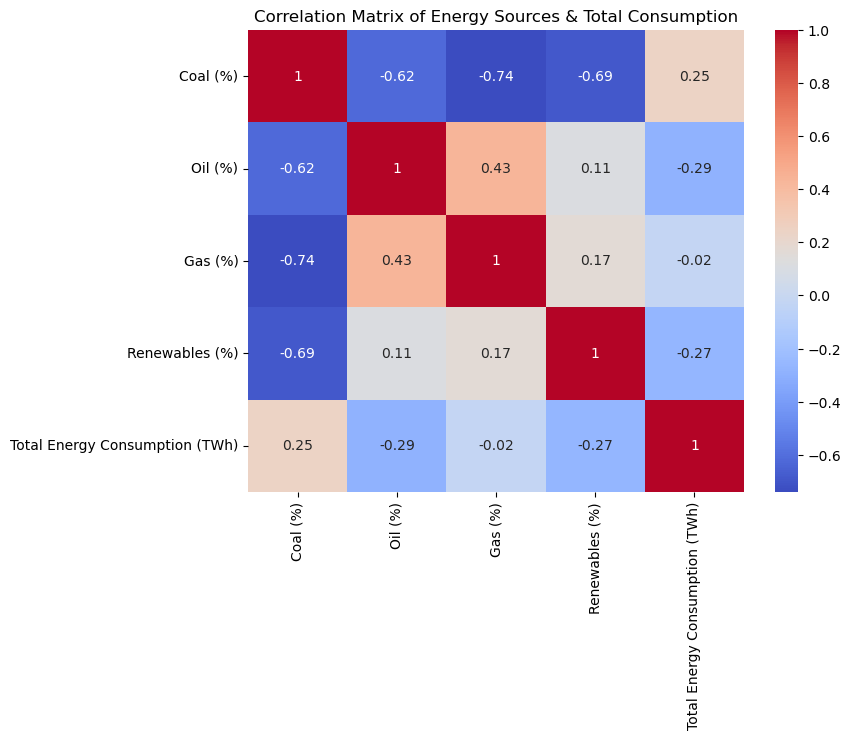

In [10]:
plt.figure(figsize=(8,6))
sns.heatmap(df[["Coal (%)","Oil (%)","Gas (%)","Renewables (%)","Total Energy Consumption (TWh)"]].corr(), 
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Energy Sources & Total Consumption")
plt.show()

In [12]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Create target variable
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Step 4: Features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]  # features
y = df['High_Consumption']  # target

# Step 5: Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Create Logistic Regression model
model = LogisticRegression()

# Step 7: Train the model
model.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Check model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print("\nModel Coefficients:")
print(coefficients)

Confusion Matrix:
[[9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Model Coefficients:
          Feature  Coefficient
0        Coal (%)    -0.114844
1         Oil (%)    -0.211826
2         Gas (%)    -0.068288
3  Renewables (%)    -0.233244


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


In [13]:
# Step 1: Import libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Create target variable
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Step 4: Features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]  # features
y = df['High_Consumption']  # target

# Step 5: Split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Create Logistic Regression model
model = LogisticRegression()

# Step 7: Train the model
model.fit(X_train, y_train)

# Step 8: Make predictions
y_pred = model.predict(X_test)

# Step 9: Evaluate the model
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Check model coefficients
coefficients = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_[0]})
print("\nModel Coefficients:")
print(coefficients)

Confusion Matrix:
[[9]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9

    accuracy                           1.00         9
   macro avg       1.00      1.00      1.00         9
weighted avg       1.00      1.00      1.00         9


Model Coefficients:
          Feature  Coefficient
0        Coal (%)    -0.114844
1         Oil (%)    -0.211826
2         Gas (%)    -0.068288
3  Renewables (%)    -0.233244


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


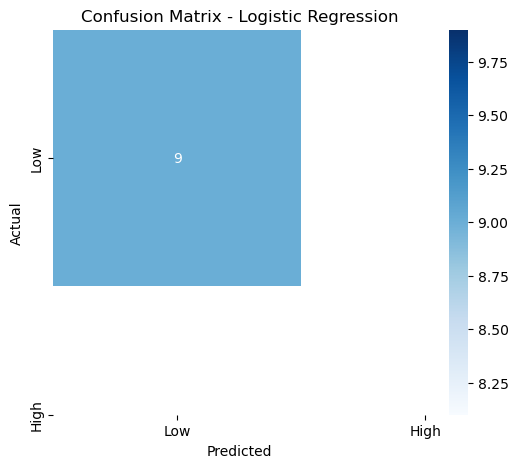

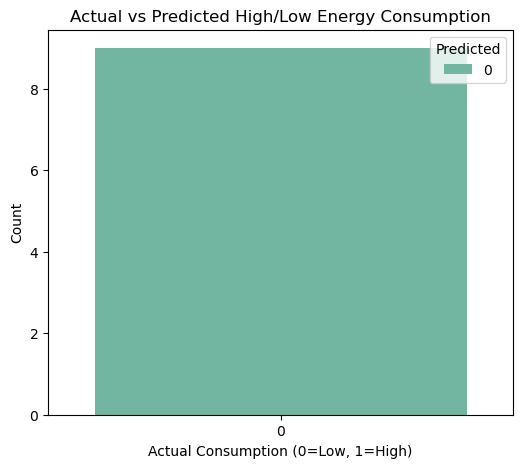

In [14]:
# Step 1: Import libraries
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Create binary target: 1 if Total > 1500 TWh, else 0
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Step 4: Features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

# Step 5: Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Train Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)

# Step 7: Predict
y_pred = model.predict(X_test)

# Step 8: Confusion Matrix visualization
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "High"], yticklabels=["Low", "High"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

# Step 9: Bar plot of predicted vs actual
df_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(6,5))
sns.countplot(data=df_pred, x='Actual', hue='Predicted', palette="Set2")
plt.title("Actual vs Predicted High/Low Energy Consumption")
plt.xlabel("Actual Consumption (0=Low, 1=High)")
plt.ylabel("Count")
plt.show()

In [16]:
# Step 1: Import libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix

# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Create binary target
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x>1500 else 0)

# Step 4: Features and target
X = df[['Coal (%)','Oil (%)','Gas (%)','Renewables (%)']]
y = df['High_Consumption']

# Step 5: Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Logistic Regression
model = LogisticRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

# =======================
# Step 7: Save Graphs
# =======================

# 7.1 Bar Chart - Total Energy by Country
plt.figure(figsize=(12,6))
sns.barplot(x="Country", y="Total Energy Consumption (TWh)", data=df, palette="viridis")
plt.xticks(rotation=90)
plt.title("Total Energy Consumption by Country - 2023")
plt.ylabel("Energy Consumption (TWh)")
plt.xlabel("Country")
plt.tight_layout()
plt.savefig("bar_total_energy.png")  # Saved as PNG
plt.close()

# 7.2 Pie Chart - USA Energy Distribution
usa = df[df["Country"]=="USA"]
labels = ["Coal (%)", "Oil (%)", "Gas (%)", "Renewables (%)"]
sizes = usa[labels].values[0]

plt.figure(figsize=(6,6))
plt.pie(sizes, labels=labels, autopct="%1.1f%%", startangle=140, colors=sns.color_palette("pastel"))
plt.title("Energy Source Distribution - USA (2023)")
plt.savefig("pie_usa_energy.png")
plt.close()

# 7.3 Stacked Bar Chart - Energy Sources by Country
df_plot = df.set_index("Country")[["Coal (%)","Oil (%)","Gas (%)","Renewables (%)"]]
ax = df_plot.plot(kind="bar", stacked=True, figsize=(12,6), colormap="tab20")
plt.ylabel("Percentage (%)")
plt.title("Energy Source Percentage by Country - 2023")
plt.xticks(rotation=90)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("stacked_energy_sources.png")
plt.close()

# 7.4 Correlation Heatmap
plt.figure(figsize=(8,6))
sns.heatmap(df[["Coal (%)","Oil (%)","Gas (%)","Renewables (%)","Total Energy Consumption (TWh)"]].corr(),
            annot=True, cmap="coolwarm")
plt.title("Correlation Matrix of Energy Sources & Total Consumption")
plt.tight_layout()
plt.savefig("correlation_heatmap.png")
plt.close()

# 7.5 Logistic Regression Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.close()

# 7.6 Logistic Regression Actual vs Predicted
df_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(6,5))
sns.countplot(data=df_pred, x='Actual', hue='Predicted', palette="Set2")
plt.title("Actual vs Predicted High/Low Energy Consumption")
plt.xlabel("Actual Consumption (0=Low, 1=High)")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("actual_vs_predicted.png")
plt.close()

print("✅ All graphs saved as images in current folder!")

C:\Users\PTCL\AppData\Local\Temp\ipykernel_12704\3773115238.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Country", y="Total Energy Consumption (TWh)", data=df, palette="viridis")
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


✅ All graphs saved as images in current folder!


Confusion Matrix:
[[7 2]
 [0 0]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.00      0.00      0.00         0

    accuracy                           0.78         9
   macro avg       0.50      0.39      0.44         9
weighted avg       1.00      0.78      0.88         9



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


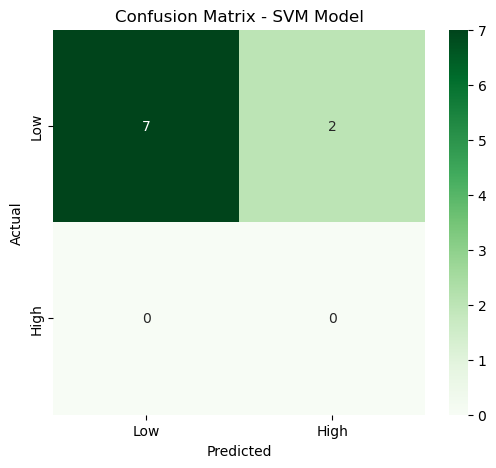

In [17]:
# Step 1: Import Libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Step 2: Load Dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Create Binary Target
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Step 4: Features and Target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

# Step 5: Split Data into Train/Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Step 6: Create SVM Model (Classification)
# kernel='linear' or 'rbf' can be used
svm_model = SVC(kernel='linear', random_state=42)

# Step 7: Train the Model
svm_model.fit(X_train, y_train)

# Step 8: Make Predictions
y_pred = svm_model.predict(X_test)

# Step 9: Evaluate the Model
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 10: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Model")
plt.show()

First 5 rows of the dataset:
   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         30 non-null     object
 1   Year                            30 non-null     int64 
 2   Coal (%)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


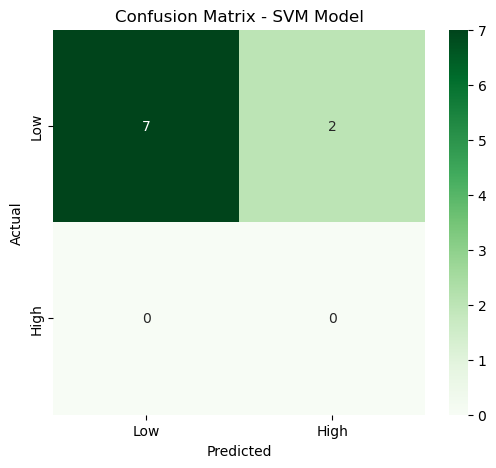

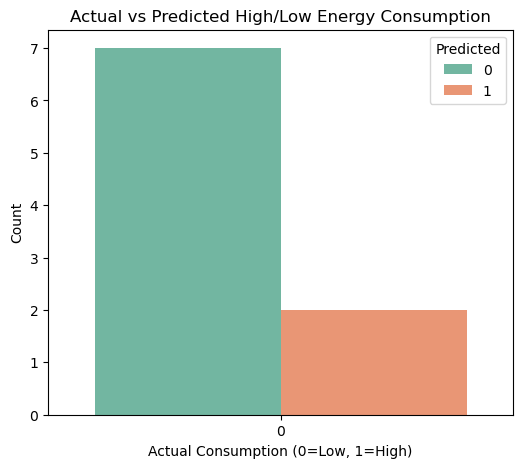

In [18]:
# ============================
# Step-by-Step SVM Classification - Global Energy Consumption
# ============================

# Step 1: Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load the dataset
# Make sure your Excel file is in the same folder or provide full path
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Step 3: Quick look at the dataset
print("First 5 rows of the dataset:")
print(df.head())
print("\nDataset info:")
print(df.info())
print("\nSummary statistics:")
print(df.describe())

# Step 4: Create binary target variable
# 1 = High energy consumption (>1500 TWh), 0 = Low consumption
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Check target distribution
print("\nTarget variable distribution:")
print(df['High_Consumption'].value_counts())

# Step 5: Select features (X) and target (y)
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]  # Features
y = df['High_Consumption']  # Target

# Step 6: Split dataset into training and testing sets
# 70% training, 30% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

print("\nNumber of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

# Step 7: Create SVM model
# 'linear' kernel is simple and easy to interpret
svm_model = SVC(kernel='linear', random_state=42)

# Step 8: Train the SVM model
svm_model.fit(X_train, y_train)

# Step 9: Make predictions on test data
y_pred = svm_model.predict(X_test)

# Step 10: Evaluate model performance
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# Classification Report (precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 11: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Model")
plt.show()

# Step 12: Visualize Actual vs Predicted counts
df_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(6,5))
sns.countplot(data=df_pred, x='Actual', hue='Predicted', palette="Set2")
plt.title("Actual vs Predicted High/Low Energy Consumption")
plt.xlabel("Actual Consumption (0=Low, 1=High)")
plt.ylabel("Count")
plt.show()

First 5 rows:
   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         30 non-null     object
 1   Year                            30 non-null     int64 
 2   Coal (%)               

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


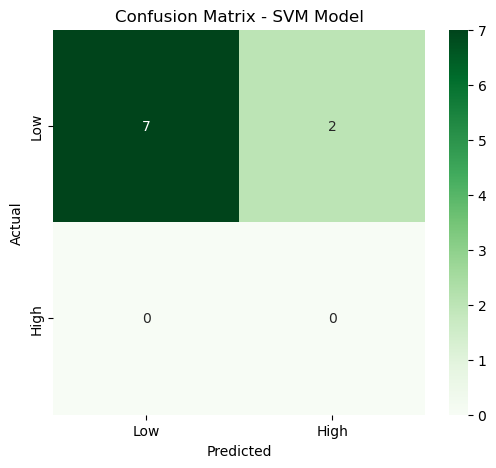

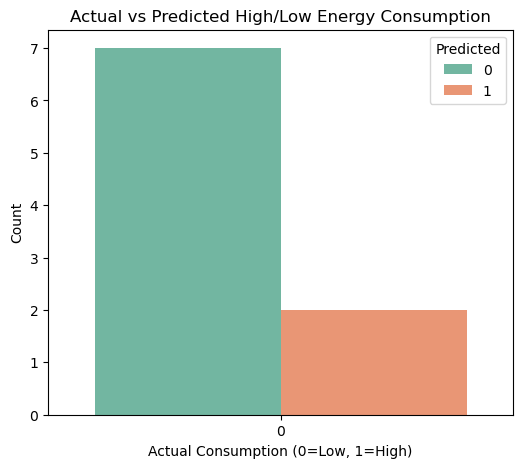

In [19]:
# ============================
# Step-by-Step SVM Classification
# Global Energy Consumption Dataset
# ============================

# Step 1: Import necessary libraries
import pandas as pd                          # For data handling
import matplotlib.pyplot as plt              # For plotting graphs
import seaborn as sns                        # For better visualization
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

# Step 2: Load the dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")  # Load Excel file

# Step 3: Explore the dataset
print("First 5 rows:")
print(df.head())                                 # Check first 5 rows
print("\nDataset info:")
print(df.info())                                 # Check column types and null values
print("\nSummary statistics:")
print(df.describe())                             # Quick statistics for numerical columns

# Step 4: Create binary target variable
# 1 = High consumption (>1500 TWh), 0 = Low consumption
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Step 5: Check distribution of target variable
print("\nTarget distribution:")
print(df['High_Consumption'].value_counts())

# Step 6: Select features (X) and target (y)
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]  # Features
y = df['High_Consumption']                                     # Target

# Step 7: Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42)                      # 70% train, 30% test

print("\nNumber of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

# Step 8: Create SVM classifier
svm_model = SVC(kernel='linear', random_state=42)              # Linear kernel for simple classification

# Step 9: Train the SVM model
svm_model.fit(X_train, y_train)

# Step 10: Make predictions on the test set
y_pred = svm_model.predict(X_test)

# Step 11: Evaluate model performance
# 11a: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

# 11b: Classification Report (precision, recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

# Step 12: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM Model")
plt.show()

# Step 13: Visualize Actual vs Predicted counts
df_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
plt.figure(figsize=(6,5))
sns.countplot(data=df_pred, x='Actual', hue='Predicted', palette="Set2")
plt.title("Actual vs Predicted High/Low Energy Consumption")
plt.xlabel("Actual Consumption (0=Low, 1=High)")
plt.ylabel("Count")
plt.show()

In [20]:
# Step 1: Import necessary libraries

import pandas as pd                          # For data handling and analysis
import matplotlib.pyplot as plt              # For plotting graphs and charts
import seaborn as sns                        # For nicer visualization
from sklearn.model_selection import train_test_split  # To split data into training/testing sets
from sklearn.svm import SVC                  # Support Vector Machine classifier
from sklearn.metrics import confusion_matrix, classification_report  # Model evaluation

In [21]:
# Step 2: Load the dataset

# Load the Global Energy Consumption Excel file into a pandas DataFrame
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Quick look at the first 5 rows to verify data loaded correctly
print("First 5 rows of the dataset:")
print(df.head())

# Check column names and data types
print("\nDataset info:")
print(df.info())

# Check basic statistics for numerical columns
print("\nSummary statistics:")
print(df.describe())

First 5 rows of the dataset:
   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  

Dataset info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         30 non-null     object
 1   Year                            30 non-null     int64 
 2   Coal (%)

In [22]:
# Step 3: Create binary target variable

# We want to classify countries as High or Low energy consumption
# Rule: If Total Energy Consumption (TWh) > 1500 → High (1)
#       Else → Low (0)
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Check the distribution of the new target variable
print("Distribution of High vs Low Energy Consumption:")
print(df['High_Consumption'].value_counts())

Distribution of High vs Low Energy Consumption:
High_Consumption
0    24
1     6
Name: count, dtype: int64


In [23]:
# Step 4: Select features (X) and target (y)

# Features: Columns that will help predict high or low energy consumption
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]

# Target: The column we want to predict
y = df['High_Consumption']

# Quick check of the features and target
print("Features (X):")
print(X.head())

print("\nTarget (y):")
print(y.head())

Features (X):
   Coal (%)  Oil (%)  Gas (%)  Renewables (%)
0        20       35       30              15
1        55       20       15              10
2        60       25       10               5
3        25       30       25              20
4         5       35       40              20

Target (y):
0    1
1    1
2    1
3    0
4    0
Name: High_Consumption, dtype: int64


In [24]:
# Step 5: Split data into training and testing sets

# Split the features (X) and target (y) into:
# 70% training data → used to train the model
# 30% testing data → used to evaluate the model
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Print the number of samples in each set
print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

Number of training samples: 21
Number of testing samples: 9


In [25]:
# Step 5: Split data into training and testing sets

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# Split the features (X) and target (y)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Print sample counts
print("Number of training samples:", X_train.shape[0])
print("Number of testing samples:", X_test.shape[0])

# =========================
# Visualize High vs Low in Training and Testing sets
# =========================
import pandas as pd

# Create a DataFrame to combine counts
train_counts = y_train.value_counts().rename('Count').reset_index().rename(columns={'index':'Class'})
train_counts['Set'] = 'Train'

test_counts = y_test.value_counts().rename('Count').reset_index().rename(columns={'index':'Class'})
test_counts['Set'] = 'Test'

plot_df = pd.concat([train_counts, test_counts])

# Plot
plt.figure(figsize=(6,5))
sns.barplot(data=plot_df, x='Class', y='Count', hue='Set', palette='Set2')
plt.title('High vs Low Energy Consumption in Train and Test Sets')
plt.xlabel('Class (0=Low, 1=High)')
plt.ylabel('Number of Samples')
plt.show()

Number of training samples: 21
Number of testing samples: 9


ValueError: Could not interpret value `Class` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x500 with 0 Axes>

In [26]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report

In [27]:
# Step 2: Load the dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Show first 5 rows
print(df.head())

# Quick info and statistics
print(df.info())
print(df.describe())

   Country  Year  Coal (%)  Oil (%)  Gas (%)  Renewables (%)  \
0      USA  2023        20       35       30              15   
1    China  2023        55       20       15              10   
2    India  2023        60       25       10               5   
3  Germany  2023        25       30       25              20   
4       UK  2023         5       35       40              20   

   Total Energy Consumption (TWh)  
0                            4000  
1                            7000  
2                            2500  
3                            1500  
4                            1200  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column                          Non-Null Count  Dtype 
---  ------                          --------------  ----- 
 0   Country                         30 non-null     object
 1   Year                            30 non-null     int64 
 2   Coal (%)                        30 non-null     int6

High_Consumption
0    24
1     6
Name: count, dtype: int64


C:\Users\PTCL\AppData\Local\Temp\ipykernel_12704\1008526042.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='High_Consumption', data=df, palette='Set1')


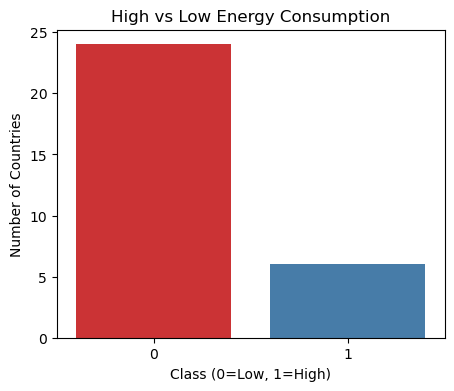

In [28]:
# Step 3: Binary target: High (1) or Low (0) energy consumption
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Check target distribution
print(df['High_Consumption'].value_counts())

# Visualize target distribution
plt.figure(figsize=(5,4))
sns.countplot(x='High_Consumption', data=df, palette='Set1')
plt.title('High vs Low Energy Consumption')
plt.xlabel('Class (0=Low, 1=High)')
plt.ylabel('Number of Countries')
plt.show()

In [29]:
# Step 4: Select features (X) and target (y)
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

# Check first rows
print(X.head())
print(y.head())

   Coal (%)  Oil (%)  Gas (%)  Renewables (%)
0        20       35       30              15
1        55       20       15              10
2        60       25       10               5
3        25       30       25              20
4         5       35       40              20
0    1
1    1
2    1
3    0
4    0
Name: High_Consumption, dtype: int64


In [30]:
# Step 5: Split data into 70% train and 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Visualize class distribution in train and test sets
train_counts = y_train.value_counts().rename('Count').reset_index().rename(columns={'index':'Class'})
train_counts['Set'] = 'Train'

test_counts = y_test.value_counts().rename('Count').reset_index().rename(columns={'index':'Class'})
test_counts['Set'] = 'Test'

plot_df = pd.concat([train_counts, test_counts])

plt.figure(figsize=(6,5))
sns.barplot(data=plot_df, x='Class', y='Count', hue='Set', palette='Set2')
plt.title('High vs Low Energy Consumption in Train/Test Sets')
plt.xlabel('Class (0=Low, 1=High)')
plt.ylabel('Number of Samples')
plt.show()

ValueError: Could not interpret value `Class` for `x`. An entry with this name does not appear in `data`.

<Figure size 600x500 with 0 Axes>

In [31]:
# Step 6: Create SVM classifier
svm_model = SVC(kernel='linear', random_state=42)

# Train the model
svm_model.fit(X_train, y_train)

# Predict test set
y_pred = svm_model.predict(X_test)

# Check first 10 predictions
print("First 10 predictions:", y_pred[:10])

First 10 predictions: [0 1 1 0 0 0 0 0 0]


Confusion Matrix:
 [[7 2]
 [0 0]]

Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.00      0.00      0.00         0

    accuracy                           0.78         9
   macro avg       0.50      0.39      0.44         9
weighted avg       1.00      0.78      0.88         9



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


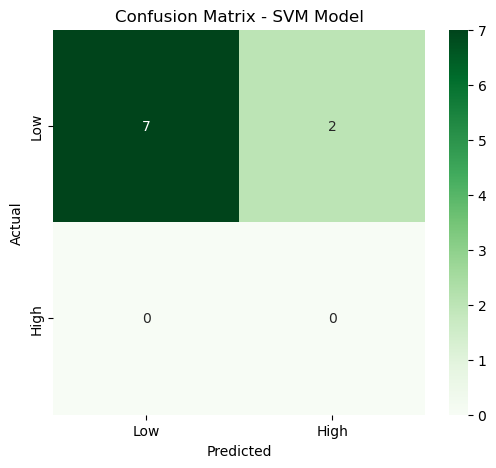

In [32]:
# Step 7a: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

# Step 7b: Classification Report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Step 7c: Visualize Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=['Low','High'], yticklabels=['Low','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - SVM Model')
plt.show()

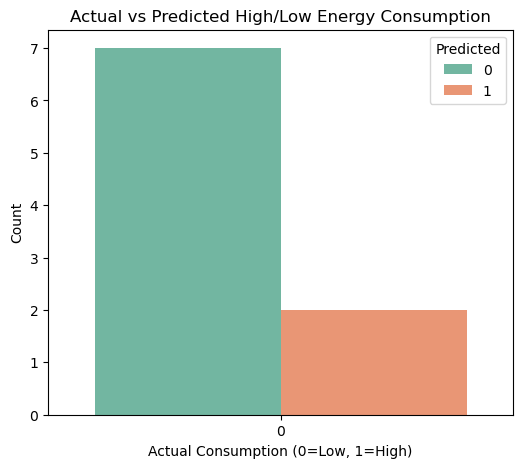

In [33]:
# Step 8: Compare Actual vs Predicted
df_pred = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(6,5))
sns.countplot(data=df_pred, x='Actual', hue='Predicted', palette='Set2')
plt.title('Actual vs Predicted High/Low Energy Consumption')
plt.xlabel('Actual Consumption (0=Low, 1=High)')
plt.ylabel('Count')
plt.show()

In [34]:
# Step 11: Calculate Accuracy of SVM Predictions

from sklearn.metrics import accuracy_score

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy
print(f"Accuracy of SVM model: {accuracy*100:.2f}%")

Accuracy of SVM model: 77.78%


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


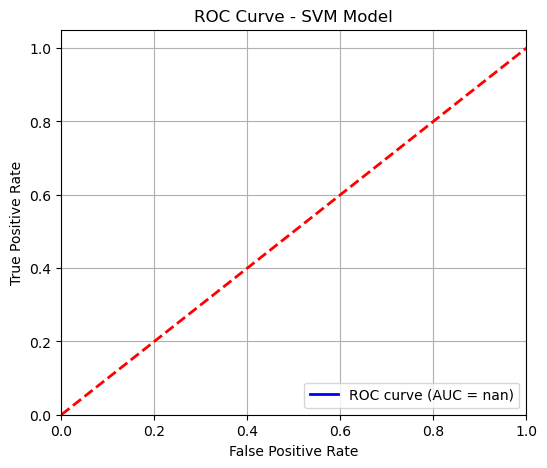

AUC of SVM model: nan


In [35]:
# Step 12: ROC Curve and AUC for SVM

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# SVM doesn't output probabilities by default, but we can use decision_function
y_scores = svm_model.decision_function(X_test)

# Calculate False Positive Rate (FPR), True Positive Rate (TPR), and thresholds
fpr, tpr, thresholds = roc_curve(y_test, y_scores)

# Calculate Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--')  # Random guess line
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - SVM Model')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("svm_roc_curve.png")  # Save figure
plt.show()

print(f"AUC of SVM model: {roc_auc:.2f}")

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(


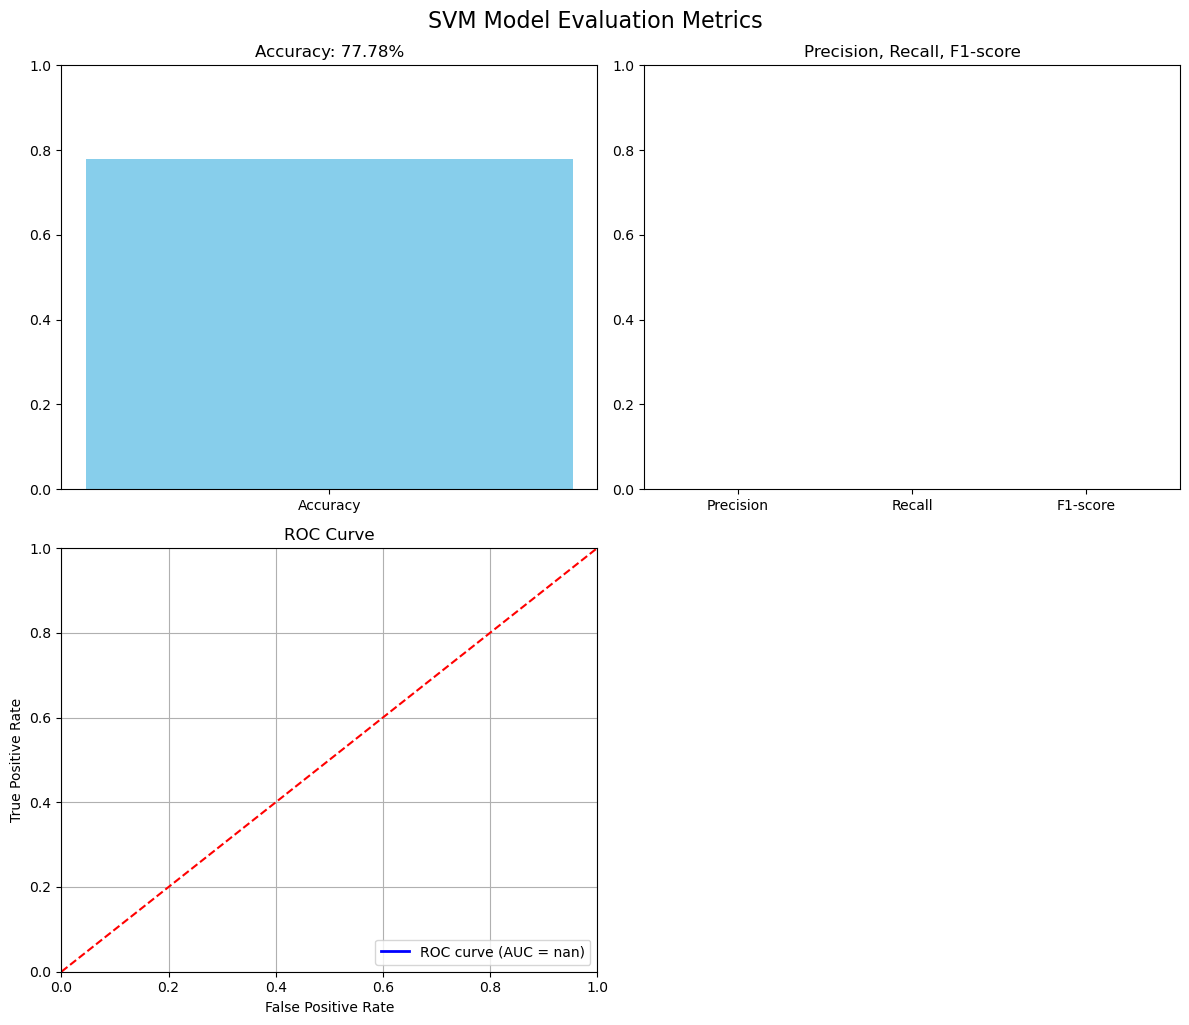

Accuracy: 77.78%
Precision: 0.00
Recall: 0.00
F1-score: 0.00
AUC: nan


In [36]:
# Step 13: Combined Evaluation Metrics Figure

from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score, roc_curve, auc

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC Curve
y_scores = svm_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Create subplots
fig, axs = plt.subplots(2, 2, figsize=(12,10))

# 1. Accuracy Bar
axs[0,0].bar(['Accuracy'], [accuracy], color='skyblue')
axs[0,0].set_ylim(0,1)
axs[0,0].set_title(f'Accuracy: {accuracy*100:.2f}%')

# 2. Precision, Recall, F1 Bar
metrics = [precision, recall, f1]
labels = ['Precision', 'Recall', 'F1-score']
axs[0,1].bar(labels, metrics, color=['green','orange','purple'])
axs[0,1].set_ylim(0,1)
axs[0,1].set_title('Precision, Recall, F1-score')

# 3. ROC Curve
axs[1,0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axs[1,0].plot([0,1], [0,1], color='red', linestyle='--')
axs[1,0].set_xlim([0,1])
axs[1,0].set_ylim([0,1])
axs[1,0].set_xlabel('False Positive Rate')
axs[1,0].set_ylabel('True Positive Rate')
axs[1,0].set_title('ROC Curve')
axs[1,0].legend(loc='lower right')
axs[1,0].grid(True)

# 4. Empty Plot (can be used for other visuals)
axs[1,1].axis('off')  # Leave empty or add another plot if needed

plt.tight_layout()
plt.suptitle('SVM Model Evaluation Metrics', fontsize=16, y=1.02)
plt.savefig("svm_combined_metrics.png")  # Save figure
plt.show()

print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-score: {f1:.2f}")
print(f"AUC: {roc_auc:.2f}")

First 10 Actual vs Predicted values:
    Actual  Predicted
27       0          0
15       0          1
23       0          1
17       0          0
8        0          0
9        0          0
28       0          0
24       0          0
12       0          0

Correct predictions: 7/9
Incorrect predictions: 2/9


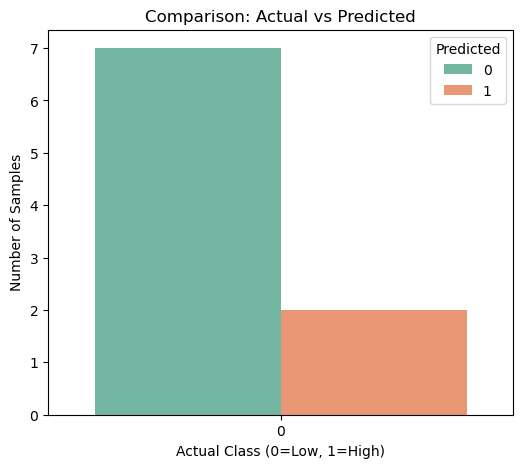

In [37]:
# Step 14: Comparison of Actual vs Predicted

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame with Actual and Predicted values
df_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

# Show first 10 rows for quick comparison
print("First 10 Actual vs Predicted values:")
print(df_comparison.head(10))

# Count of correct vs incorrect predictions
df_comparison['Correct'] = df_comparison['Actual'] == df_comparison['Predicted']
correct_count = df_comparison['Correct'].sum()
total_count = len(df_comparison)
print(f"\nCorrect predictions: {correct_count}/{total_count}")
print(f"Incorrect predictions: {total_count - correct_count}/{total_count}")

# ===============================
# Visual Comparison (bar plot)
# ===============================
plt.figure(figsize=(6,5))
sns.countplot(data=df_comparison, x='Actual', hue='Predicted', palette='Set2')
plt.title('Comparison: Actual vs Predicted')
plt.xlabel('Actual Class (0=Low, 1=High)')
plt.ylabel('Number of Samples')
plt.legend(title='Predicted')
plt.savefig("svm_actual_vs_predicted_comparison.png")  # Save figure
plt.show()

In [38]:
# Step: Calculate Accuracy of SVM Predictions

from sklearn.metrics import accuracy_score

# y_test → Actual labels
# y_pred → Predicted labels by SVM
accuracy = accuracy_score(y_test, y_pred)

# Print accuracy as a percentage
print(f"Accuracy of SVM model: {accuracy*100:.2f}%")

Accuracy of SVM model: 77.78%


C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Us

======= SVM MODEL FINAL METRICS =======
Accuracy : 77.78%
Precision: 0.00
Recall   : 0.00
F1-score : 0.00
AUC      : nan

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.00      0.00      0.00         0

    accuracy                           0.78         9
   macro avg       0.50      0.39      0.44         9
weighted avg       1.00      0.78      0.88         9



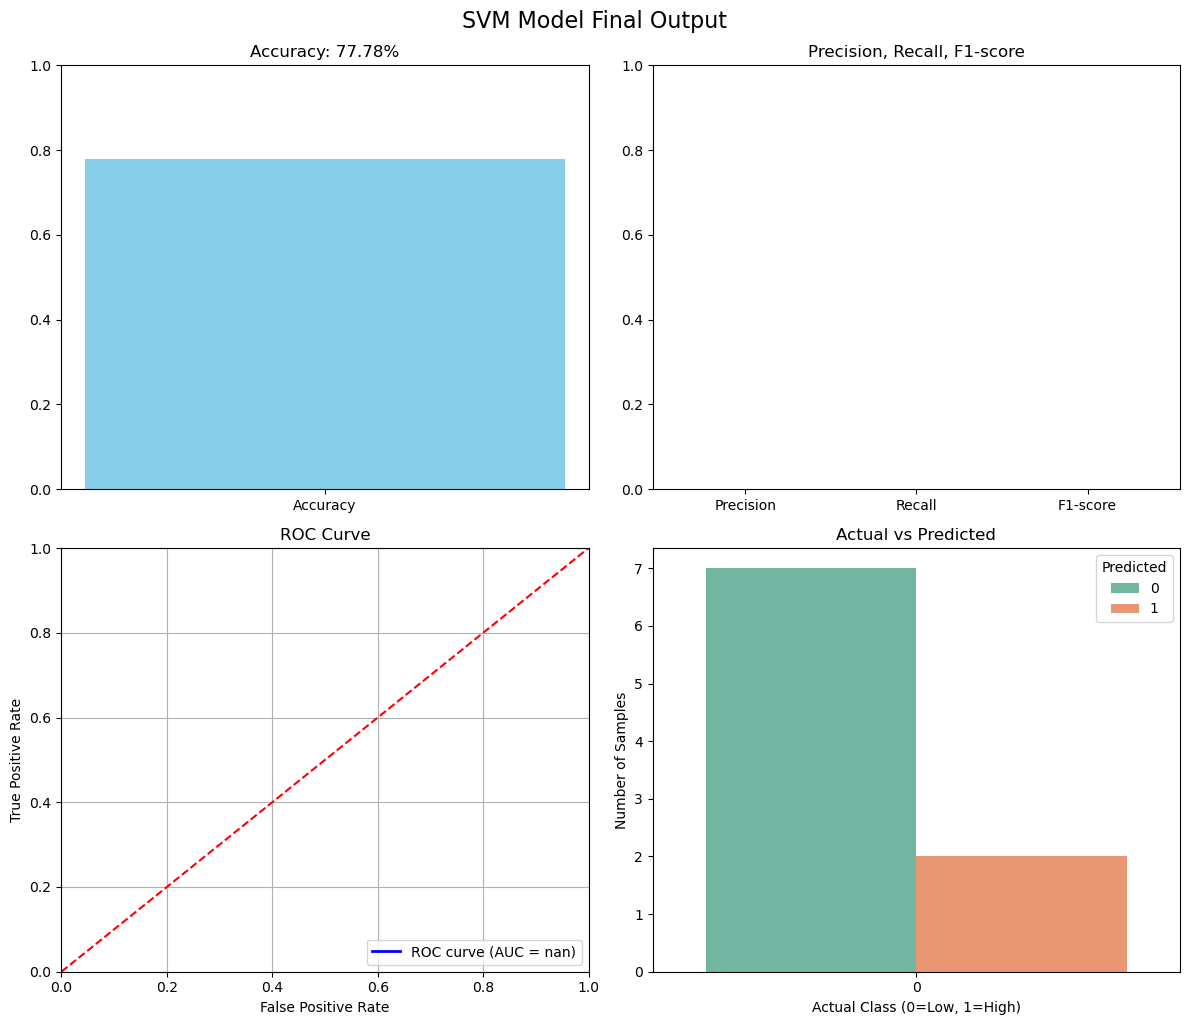

In [39]:
# ===============================
# FINAL OUTPUT - SVM MODEL EVALUATION
# ===============================

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, classification_report, confusion_matrix

# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC Curve and AUC
y_scores = svm_model.decision_function(X_test)
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Print Metrics
print("======= SVM MODEL FINAL METRICS =======")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")
print(f"AUC      : {roc_auc:.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

# ===============================
# Visualizations
# ===============================

fig, axs = plt.subplots(2, 2, figsize=(12,10))

# Accuracy
axs[0,0].bar(['Accuracy'], [accuracy], color='skyblue')
axs[0,0].set_ylim(0,1)
axs[0,0].set_title(f'Accuracy: {accuracy*100:.2f}%')

# Precision, Recall, F1-score
metrics = [precision, recall, f1]
labels = ['Precision', 'Recall', 'F1-score']
axs[0,1].bar(labels, metrics, color=['green','orange','purple'])
axs[0,1].set_ylim(0,1)
axs[0,1].set_title('Precision, Recall, F1-score')

# ROC Curve
axs[1,0].plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
axs[1,0].plot([0,1], [0,1], color='red', linestyle='--')
axs[1,0].set_xlim([0,1])
axs[1,0].set_ylim([0,1])
axs[1,0].set_xlabel('False Positive Rate')
axs[1,0].set_ylabel('True Positive Rate')
axs[1,0].set_title('ROC Curve')
axs[1,0].legend(loc='lower right')
axs[1,0].grid(True)

# Actual vs Predicted
df_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
sns.countplot(data=df_comparison, x='Actual', hue='Predicted', palette='Set2', ax=axs[1,1])
axs[1,1].set_title('Actual vs Predicted')
axs[1,1].set_xlabel('Actual Class (0=Low, 1=High)')
axs[1,1].set_ylabel('Number of Samples')

plt.tight_layout()
plt.suptitle('SVM Model Final Output', fontsize=16, y=1.02)
plt.savefig("svm_final_output.png")  # Save final figure
plt.show()

In [40]:
# Step 1: Import libraries for Decision Tree
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

In [41]:
# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Create binary target: High (>1500 TWh) = 1, Low <=1500 = 0
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Select features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

In [42]:
# Step 3: Split data 70% train / 30% test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [43]:
# Step 4: Create Decision Tree Classifier
dt_model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=42)

# Train the model
dt_model.fit(X_train, y_train)

# Predict on test set
y_pred = dt_model.predict(X_test)

In [44]:
# Step 5: Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC and AUC
y_scores = dt_model.predict_proba(X_test)[:,1]  # Decision Tree gives probabilities
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Print metrics
print("======= Decision Tree Metrics =======")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")
print(f"AUC      : {roc_auc:.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

======= Decision Tree Metrics =======
Accuracy : 88.89%
Precision: 0.00
Recall   : 0.00
F1-score : 0.00
AUC      : nan

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.89      0.94         9
           1       0.00      0.00      0.00         0

    accuracy                           0.89         9
   macro avg       0.50      0.44      0.47         9
weighted avg       1.00      0.89      0.94         9



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Us

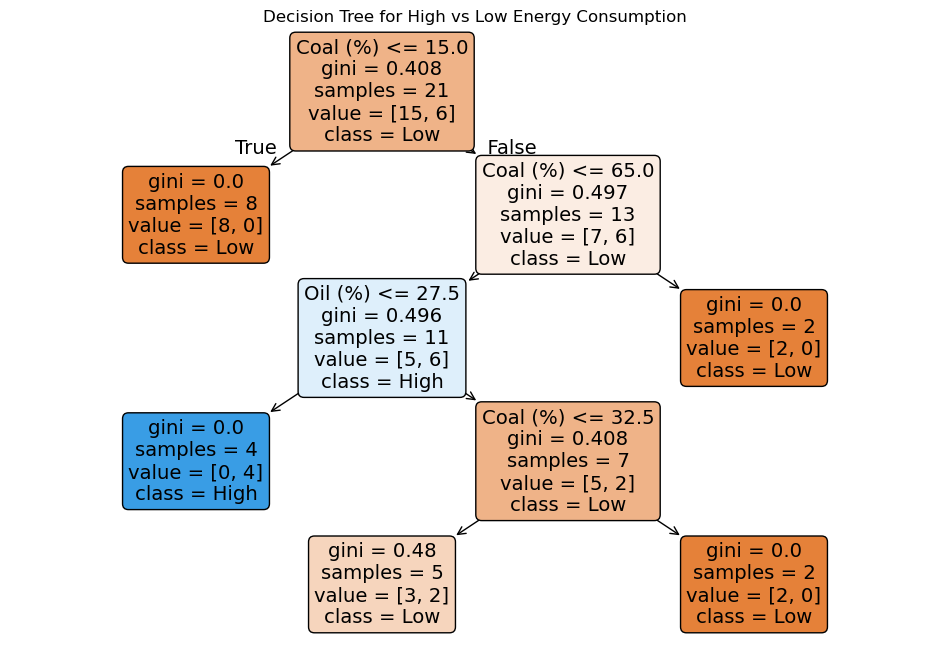

In [45]:
# Step 6: Visualize the tree
plt.figure(figsize=(12,8))
plot_tree(dt_model, feature_names=X.columns, class_names=['Low','High'], filled=True, rounded=True)
plt.title('Decision Tree for High vs Low Energy Consumption')
plt.savefig("decision_tree.png")  # Save figure
plt.show()

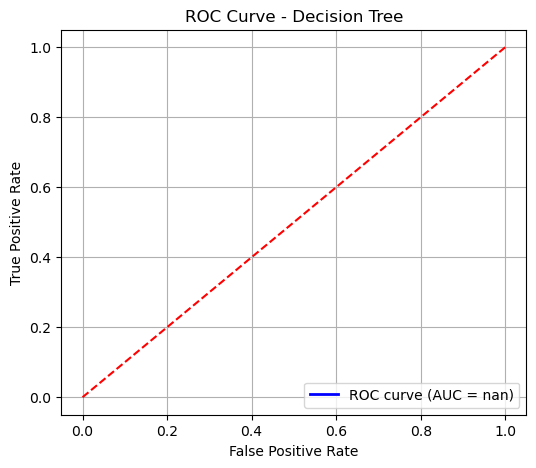

In [46]:
# Step 7: ROC curve for Decision Tree
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0,1], [0,1], color='red', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Decision Tree')
plt.legend(loc='lower right')
plt.grid(True)
plt.savefig("decision_tree_roc.png")
plt.show()

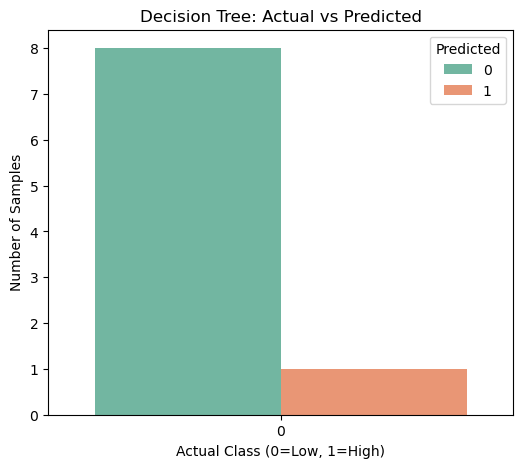

In [47]:
# Step 8: Compare Actual vs Predicted
df_comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})

plt.figure(figsize=(6,5))
sns.countplot(data=df_comparison, x='Actual', hue='Predicted', palette='Set2')
plt.title('Decision Tree: Actual vs Predicted')
plt.xlabel('Actual Class (0=Low, 1=High)')
plt.ylabel('Number of Samples')
plt.savefig("decision_tree_actual_vs_predicted.png")
plt.show()

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

In [49]:
# Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Binary target: High (>1500 TWh) = 1, Low <=1500 = 0
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

In [50]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [51]:
# Create Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)

# Train the model
rf_model.fit(X_train, y_train)

# Predict on test set
y_pred = rf_model.predict(X_test)

In [52]:
# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

# ROC & AUC
y_scores = rf_model.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores)
roc_auc = auc(fpr, tpr)

# Print metrics
print("======= Random Forest Metrics =======")
print(f"Accuracy : {accuracy*100:.2f}%")
print(f"Precision: {precision:.2f}")
print(f"Recall   : {recall:.2f}")
print(f"F1-score : {f1:.2f}")
print(f"AUC      : {roc_auc:.2f}")
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

======= Random Forest Metrics =======
Accuracy : 77.78%
Precision: 0.00
Recall   : 0.00
F1-score : 0.00
AUC      : nan

Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.78      0.88         9
           1       0.00      0.00      0.00         0

    accuracy                           0.78         9
   macro avg       0.50      0.39      0.44         9
weighted avg       1.00      0.78      0.88         9



C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 due to no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_ranking.py:1201: UndefinedMetricWarning: No positive samples in y_true, true positive value should be meaningless
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\ProgramData\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Us

In [53]:
# Step 1: Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, roc_curve, auc

In [54]:
# Step 2: Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

# Binary target: High (>1500 TWh) = 1, Low <=1500 = 0
df['High_Consumption'] = df['Total Energy Consumption (TWh)'].apply(lambda x: 1 if x > 1500 else 0)

# Features and target
X = df[['Coal (%)', 'Oil (%)', 'Gas (%)', 'Renewables (%)']]
y = df['High_Consumption']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load dataset
df = pd.read_excel("Global_Energy_Consumption.xlsx")

countries = ["USA", "China", "India", "Germany"]

fig, axs = plt.subplots(2, 2, figsize=(10,10))

for i, country in enumerate(countries):
    row = i // 2
    col = i % 2
    
    data = df[df["Country"] == country]
    sizes = data[["Coal (%)","Oil (%)","Gas (%)","Renewables (%)"]].values[0]
    
    axs[row, col].pie(sizes, labels=["Coal","Oil","Gas","Renewables"], autopct="%1.1f%%")
    axs[row, col].set_title(country)

plt.tight_layout()
plt.savefig("pie_all_countries.png")
plt.show()